In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('Sample SuperStore.xlsx')

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display column names and their data types
print("\nColumn information:")
print(df.info())

First 5 rows of the dataset:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0  

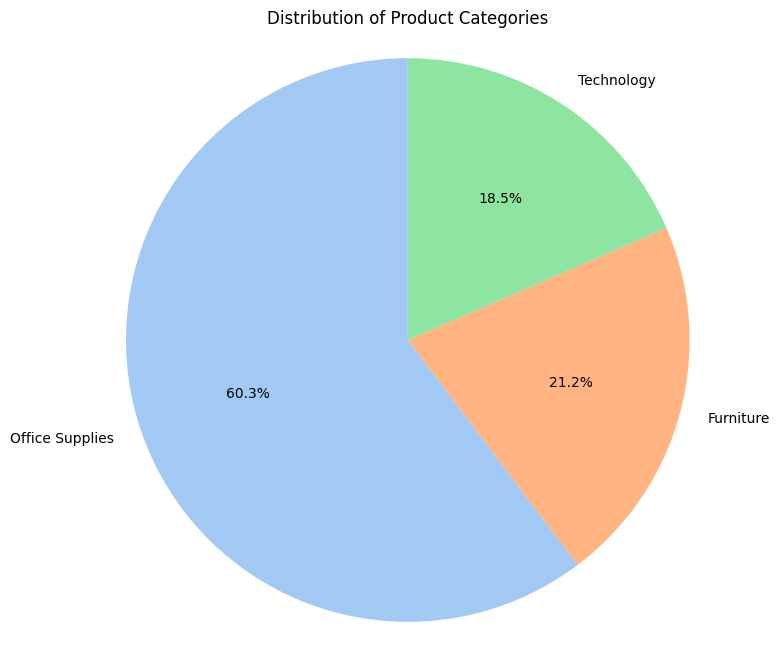

In [3]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(8, 8))
sns.set_palette('pastel') # Using a seaborn color palette
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Product Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

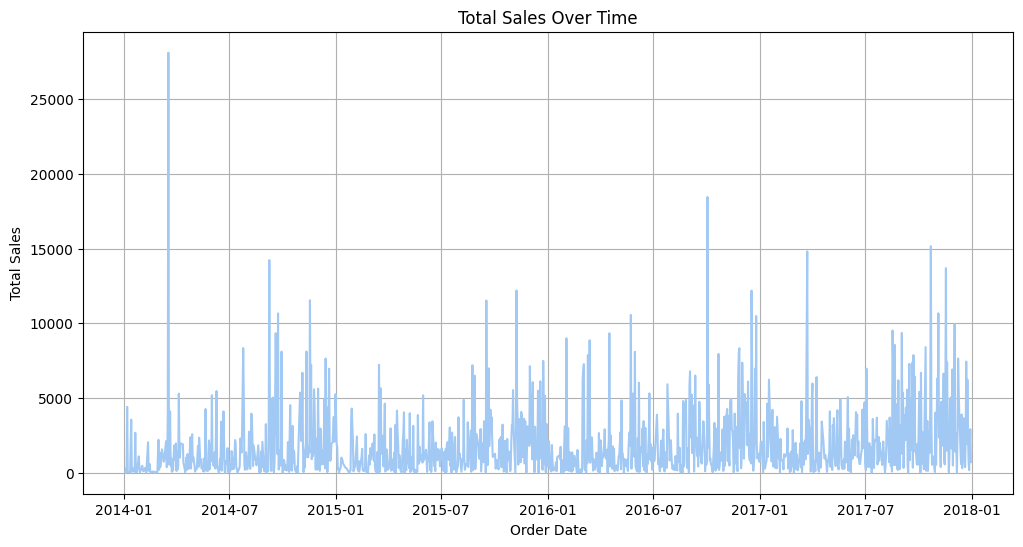

In [4]:
sales_over_time = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_over_time, x='Order Date', y='Sales')
plt.title('Total Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

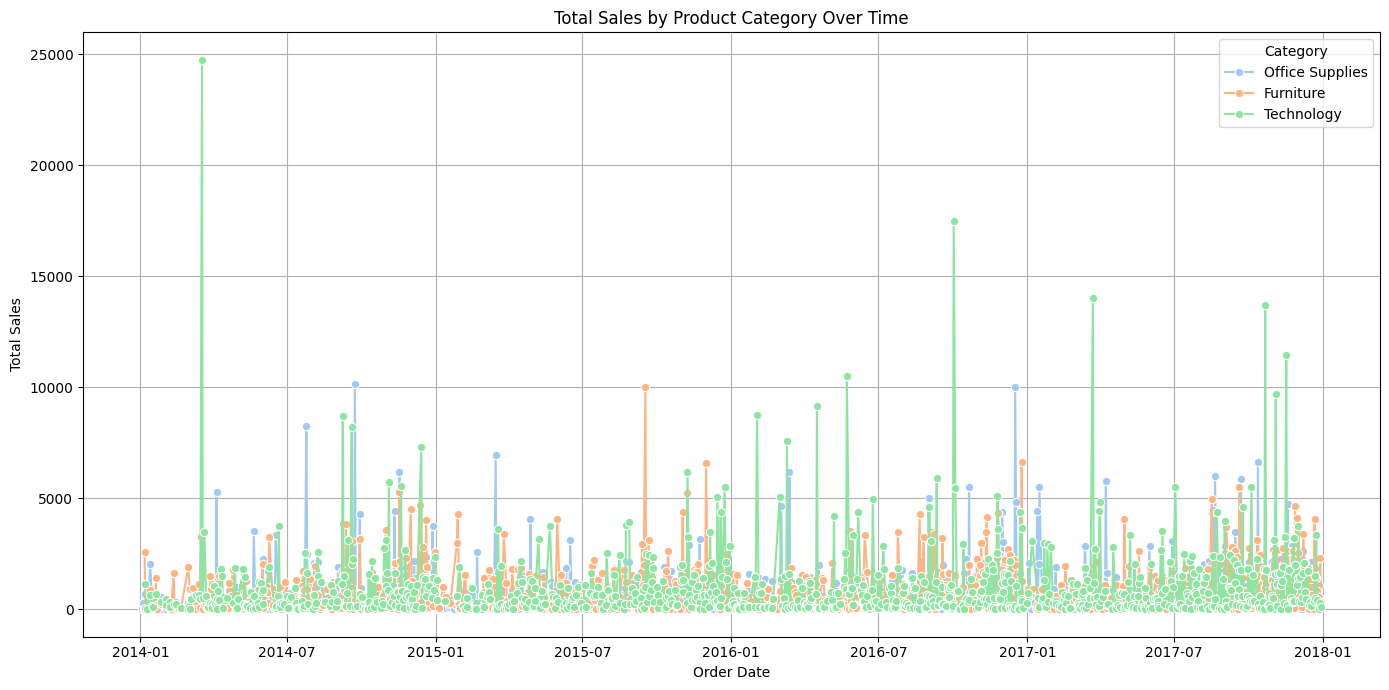

In [5]:
sales_by_category_over_time = df.groupby(['Order Date', 'Category'])['Sales'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=sales_by_category_over_time, x='Order Date', y='Sales', hue='Category', marker='o', errorbar=None)
plt.title('Total Sales by Product Category Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

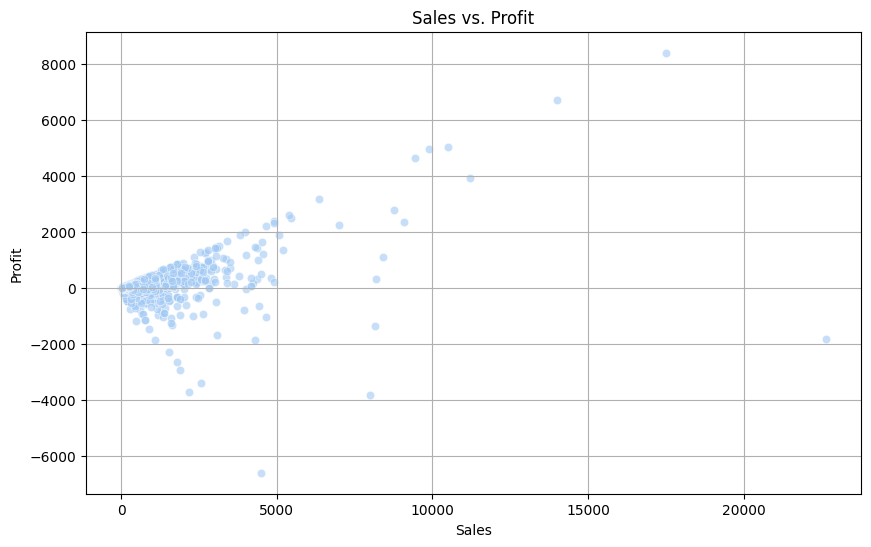

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.6)
plt.title('Sales vs. Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

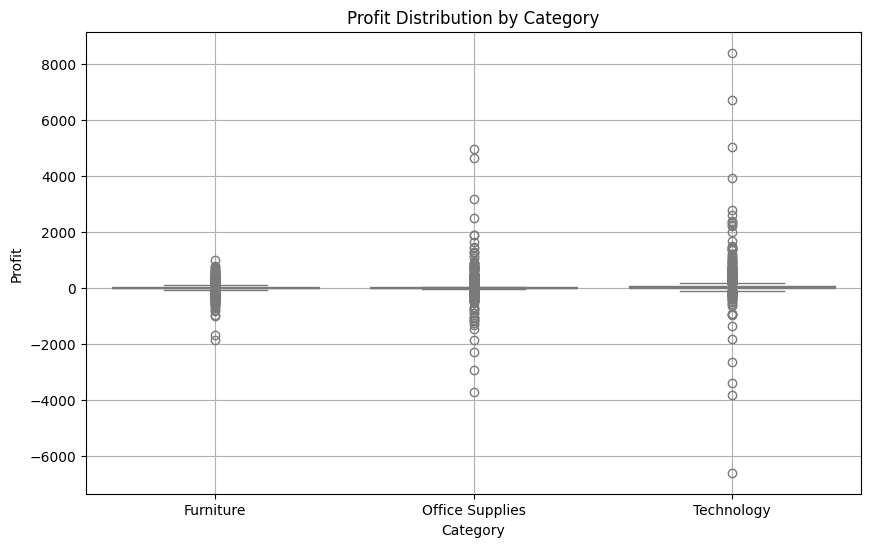

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

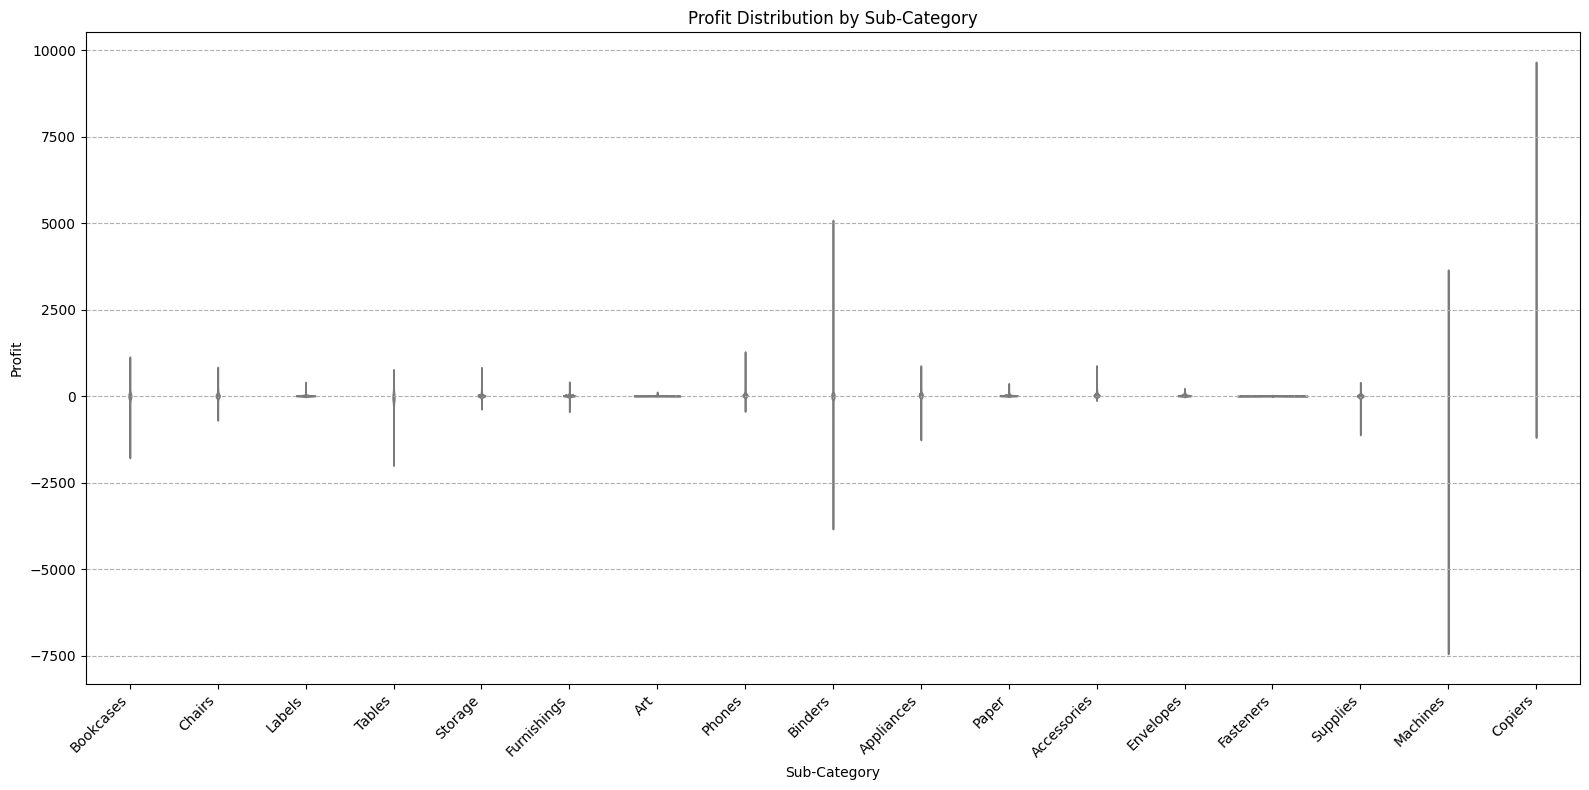

In [8]:
plt.figure(figsize=(16, 8))
sns.violinplot(data=df, x='Sub-Category', y='Profit', inner='quartile')
plt.title('Profit Distribution by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [9]:
import plotly.express as px

subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()

fig = px.treemap(subcategory_sales,
                 path=['Sub-Category'],
                 values='Sales',
                 title='Sales by Sub-Category Treemap',
                 color_continuous_scale='RdBu')

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

In [12]:
median_discount = df['Discount'].median()
median_profit = df['Profit'].median()

high_discount_low_profit_rows = df[(df['Discount'] > median_discount) & (df['Profit'] < median_profit)]

print(f"Rows where Discount is higher than {median_discount:.2f} and Profit is lower than {median_profit:.2f}:")
display(high_discount_low_profit_rows.head())

Rows where Discount is higher than 0.20 and Profit is lower than 8.67:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522


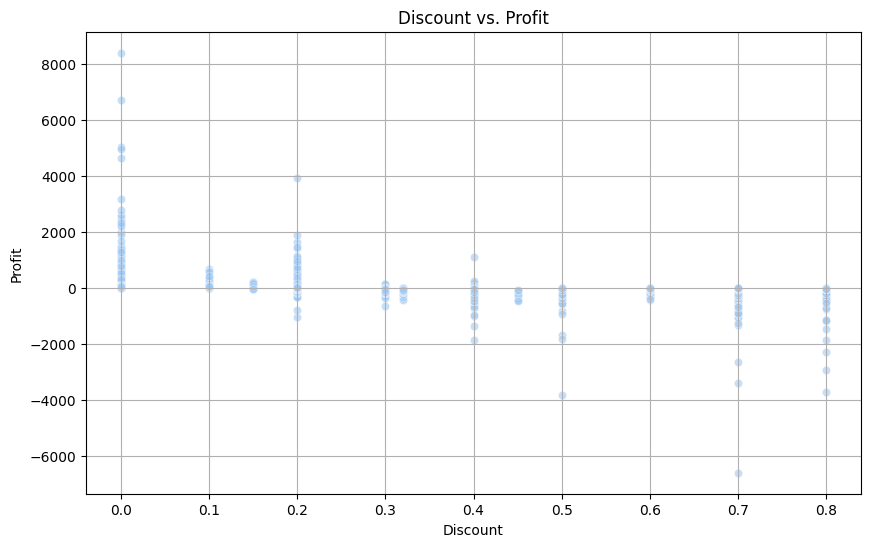

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.6)
plt.title('Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

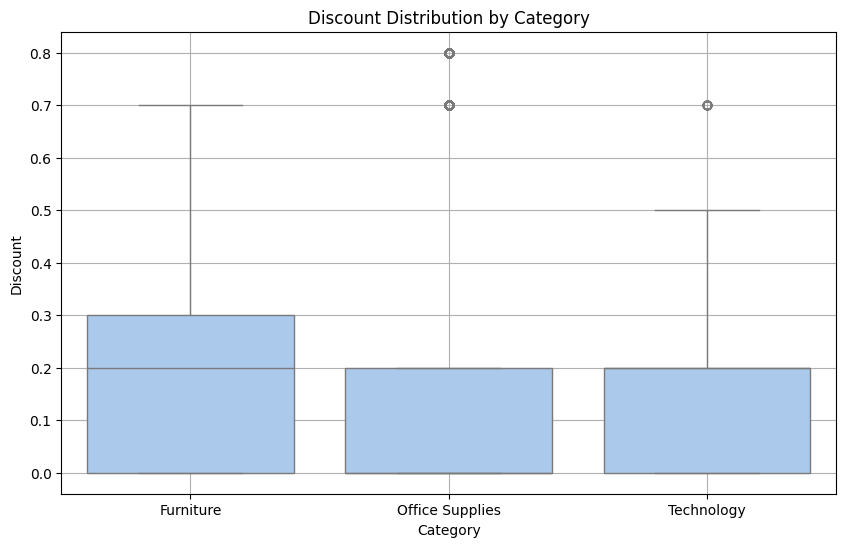

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Discount')
plt.title('Discount Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Discount')
plt.grid(True)
plt.show()